In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from dadk.BinPol import *

#### Input dataset

In [2]:
### Ecosystem of batteries

In [2]:
req_final_energy_perc = 30
initial_energy_perc = 50

df_bat = pd.DataFrame()
df_bat['Type'] = ['EV', 'C&I', 'Residential']
df_bat['Quantity'] = [2, 1, 2]
df_bat['Capacity(kWh)'] = [200, 2000, 20]
df_bat['Charging_rate(kW)'] = [20, 200, 10]
df_bat['Dicharging_rate(kW)'] = [10, 100, 5]
df_bat['C_eff(%)'] = [90, 90, 90]
df_bat['D_eff(%)'] = [90, 90, 90]
df_bat['E_initial(kWh)'] = (df_bat['Capacity(kWh)']*initial_energy_perc/100).astype(int) #### It can be randomized
df_bat['E_required(kWh)'] = (df_bat['Capacity(kWh)']*req_final_energy_perc/100).astype(int) #### It can be randomized
df_bat

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,2,200,20,10,90,90,100,60
1,C&I,1,2000,200,100,90,90,1000,600
2,Residential,2,20,10,5,90,90,10,6


In [3]:
# Repeat each row by its Quantity
df_expanded = df_bat.loc[df_bat.index.repeat(df_bat['Quantity'])].reset_index(drop=True)

# Set Quantity to 1 for each battery
df_expanded['Quantity'] = 1

df_expanded

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,1,200,20,10,90,90,100,60
1,EV,1,200,20,10,90,90,100,60
2,C&I,1,2000,200,100,90,90,1000,600
3,Residential,1,20,10,5,90,90,10,6
4,Residential,1,20,10,5,90,90,10,6


In [4]:
### Normalize capacities

In [4]:
### Tranformer maximum capacity

K = 10000 ### expressed in kW

In [5]:
### Trading window

T = 8 ### expressed in hours

In [6]:
### Number of batteries

num_batteries = df_bat['Quantity'].sum()

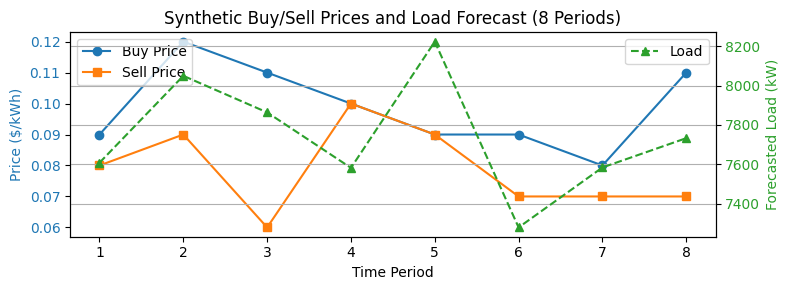

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Number of time periods
T = T

# Generate synthetic data
buy_prices = np.random.uniform(80/1000, 120/1000, T).round(2)
sell_prices = np.random.uniform(60/1000, 100/1000, T).round(2)
load = np.random.uniform(7000, 9000, T).round()

# Create DataFrame
df = pd.DataFrame({
    "Time Period": np.arange(1, T + 1),
    "Buy Price ($/kWh)": buy_prices,
    "Sell Price ($/kWh)": sell_prices,
    "Forecasted Load (kW)": load
})

# Plot
fig, ax1 = plt.subplots(figsize=(8, 3))
ax1.set_title("Synthetic Buy/Sell Prices and Load Forecast (8 Periods)")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Price ($/kWh)", color='tab:blue')
ax1.plot(df["Time Period"], df["Buy Price ($/kWh)"], label="Buy Price", marker='o', color='tab:blue')
ax1.plot(df["Time Period"], df["Sell Price ($/kWh)"], label="Sell Price", marker='s', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc="upper left")

# Second y-axis for load
ax2 = ax1.twinx()
ax2.set_ylabel("Forecasted Load (kW)", color='tab:green')
ax2.plot(df["Time Period"], df["Forecasted Load (kW)"], label="Load", marker='^', linestyle='--', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.legend(loc="upper right")

plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Create desired output DataFrame
output_df = pd.DataFrame({
    "timestamp": df["Time Period"],
    "excess_capacity(kW)": (K - df["Forecasted Load (kW)"]).astype(int)
})
output_df

,timestamp,excess_capacity(kW)
0,1,2392
1,2,1950
2,3,2136
3,4,2418
4,5,1776
5,6,2721
6,7,2416
7,8,2267


# Create problem variables

In [9]:
my_bit_charging_indicator_array = BitArrayShape(name='charging_array', shape=(df_bat['Quantity'].sum(),T), axis_names=['battery','interval'])
my_bit_discharging_indicator_array = BitArrayShape(name='discharging_array', shape=(df_bat['Quantity'].sum(),T), axis_names=['battery','interval'])

## Slack Variables

##### 1) Slack for consecutive charging and discharging: No consecutive charging or discharging up to 3 periods

In [10]:
slack_consec_charg_list = []

for i in range(num_batteries):
    slack_var_name = f"slack_consec_charge_battery_{i}"
    slack_consec_charg_list.append(VarSlack(name=slack_var_name,start=0,step=1,stop=3,slack_type=SlackType.binary))


slack_consec_discharg_list = []

for i in range(num_batteries):
    slack_var_name = f"slack_consec_discharge_battery_{i}"
    slack_consec_discharg_list.append(VarSlack(name=slack_var_name,start=0,step=1,stop=3,slack_type=SlackType.binary))

In [11]:
my_varshapeset = VarShapeSet(my_bit_charging_indicator_array,
                             my_bit_discharging_indicator_array,
                             *slack_consec_charg_list,
                             *slack_consec_discharg_list)

## Constraints

##### 1) Exclusivity (HARD): No charging and discharging at the same time

In [12]:
H_exclusive = BinPol(my_varshapeset)

for i in range(num_batteries):
    for t in range(T):
        H_exclusive.add_term(1, (("charging_array", i, t), ("discharging_array", i, t)))

# Now normalization works
H_exclusive_normalized = H_exclusive * (1 / (num_batteries * T))

##### 2) Consecutive charging/discharging (SOFT): No consecutive charging and discharging periods

In [13]:
H_consec_charging = BinPol(my_varshapeset)

for i in range(num_batteries):
    
    H_consec_sub_char = BinPol(my_varshapeset)
    
    for t in range(T - 3):
        
        H_consec_sub_char.add_term(1, (("charging_array", i, t),))
        H_consec_sub_char.add_term(1, (("charging_array", i, t+1),))
        H_consec_sub_char.add_term(1, (("charging_array", i, t+2),))

    # Build the quadratic penalty
    H_consec_charging += ((H_consec_sub_char - 2).add_variable('slack_consec_charge_battery_'+str(i))) ** 2

H_consec_charging *= 1 / (num_batteries * (T - 2))

In [14]:
H_consec_discharging = BinPol(my_varshapeset)

for i in range(num_batteries):
    
    H_consec_sub_dischar = BinPol(my_varshapeset)
    
    for t in range(T - 3):
        
        H_consec_sub_dischar.add_term(1, (("discharging_array", i, t),))
        H_consec_sub_dischar.add_term(1, (("discharging_array", i, t+1),))
        H_consec_sub_dischar.add_term(1, (("discharging_array", i, t+2),))

    # Build the quadratic penalty
    H_consec_discharging += ((H_consec_sub_dischar - 2).add_variable('slack_consec_discharge_battery_'+str(i))) ** 2

H_consec_discharging *= 1 / (num_batteries * (T - 2))

##### 3) Transformer capacity limit (HARD)

In [15]:
H_transformer_capacity = BinPol(my_varshapeset)

scale_factor = float(output_df['excess_capacity(kW)'].max())

for t in range(T):
    H_sub = BinPol(my_varshapeset)
    
    for i in range(num_batteries):
        eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
        eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
        charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
        discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']

        H_sub.add_term(eff_c * charge_rate, (("charging_array", i, t),))
        H_sub.add_term(-1/eff_d * discharge_rate, (("discharging_array", i, t),))

    Kt = float(output_df.iloc[t]['excess_capacity(kW)'])  #### Kt = Lt - K

    H_transformer_capacity += (H_sub - Kt) ** 2

# Normalize after summation
H_transformer_capacity_normalized = H_transformer_capacity * (1 / scale_factor**2)

## Objective(s)

##### 1) Maximize profit versus loss

In [16]:
# Estimate max value
max_main = 0.0
for i in range(num_batteries):
    eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
    eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
    charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
    discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']
    for t in range(T):
        max_main += max(abs(eff_c * charge_rate), abs(eff_d * discharge_rate))

# Build and normalize H_main
H_main = BinPol(my_varshapeset)
for i in range(num_batteries):
    eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
    eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
    charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
    discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']
    for t in range(T):
        buy_price = df.iloc[t]['Buy Price ($/kWh)']
        sell_price = df.iloc[t]['Sell Price ($/kWh)']
        H_main.add_term(eff_c * charge_rate * buy_price, (("charging_array", i, t),))
        H_main.add_term(-1/eff_d * discharge_rate * sell_price, (("discharging_array", i, t),))

# Normalize and scale
H_main_normalized = (H_main / max_main)

##### 2) Maximize user satisfaction

In [17]:
H_energy_tracking = BinPol(my_varshapeset)


for i in range(num_batteries):
    
    E_o_i = df_expanded.iloc[i]['E_initial(kWh)']
    E_r_i = df_expanded.iloc[i]['E_required(kWh)']
    eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
    eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
    charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
    discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']
    
    H_energy_i_t = BinPol(my_varshapeset)

    E_diff = float(E_o_i - E_r_i)
    
    for t in range(T):
        
        # Add cumulative sum from v=0 to t
        for v in range(t + 1):
            
            H_energy_i_t.add_term(eff_c * charge_rate, (("charging_array", i, v),))
            H_energy_i_t.add_term(-1/eff_d * discharge_rate, (("discharging_array", i, v),))

        # Square the deviation
    H_energy_tracking += (H_energy_i_t + E_diff) ** 2


E_initial = list(df_expanded['E_initial(kWh)'])
E_required = list(df_expanded['E_required(kWh)'])

scale_E = max(abs(np.array(E_initial) - np.array(E_required))) + 1  # Add 1 to avoid div/0
H_energy_tracking_normalized = H_energy_tracking * (1 / (scale_E**2 * T * num_batteries))

## Executing

In [74]:
#Constuimos la función de coste con el término principal y todas las constraints:


#### These lambdas worked for me ####
#### These lambdas worked for me ####
#### These lambdas worked for me ####
# lambda_main1 = 1
# lambda_main2 = 100
# lambda_exclusivity = 8
# lambda_consec_char = 0.5
# lambda_consec_dischar = 0.5
# lambda_transf = 0.5
#### These lambdas worked for me ####
#### These lambdas worked for me ####
#### These lambdas worked for me ####


lambda_main1 = 50
lambda_main2 = 300
lambda_exclusivity = 10
lambda_consec_char = 1
lambda_consec_dischar = 1
lambda_transf = 5

cost_function = (lambda_main1*H_main_normalized +
                lambda_main2*H_energy_tracking_normalized +
                lambda_exclusivity*H_exclusive_normalized +
                lambda_consec_char*H_consec_charging +
                lambda_consec_dischar*H_consec_discharging +
                lambda_transf*H_transformer_capacity_normalized)

In [75]:
from dadk.QUBOSolverCPU import *

start_time = time.time()

solver = QUBOSolverCPU(
number_iterations=500000,
number_runs=100,
scaling_bit_precision=32,
auto_tuning=AutoTuning.AUTO_SCALING_AND_SAMPLING)

solution_list = solver.minimize(cost_function)

solution = solution_list.get_minimum_energy_solution()

end_time = time.time()
elapsed_time = end_time - start_time

print(f"Elapsed time: {elapsed_time:.4f} seconds")


********************************************************************************
  temperature_start:                       1.50306003e+00
  temperature_end:                         1.70560020e-01
  offset_increase_rate:                    4.66088100e-01
  duration:                                0.008 sec
********************************************************************************

  max_abs_coefficient:                    169.386

********************************************************************************
Effective values (including scaling factor)
  scaling_factor:                           1.26767780e+07
  temperature_start:                        1.90539583e+07
  temperature_end:                          2.16215151e+06
  offset_increase_rate:                     5.90849537e+06
  duration:                                 0.001 sec
********************************************************************************

Elapsed time: 143.7230 seconds


In [76]:
my_bit_charging_array = solution.extract_bit_array("charging_array")
my_bit_discharging_array = solution.extract_bit_array("discharging_array")

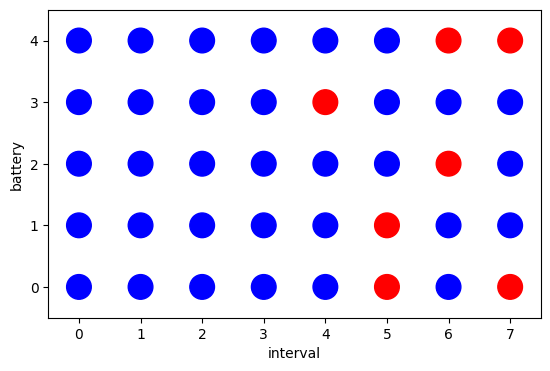

In [77]:
my_bit_charging_array.draw(order=[1,0])

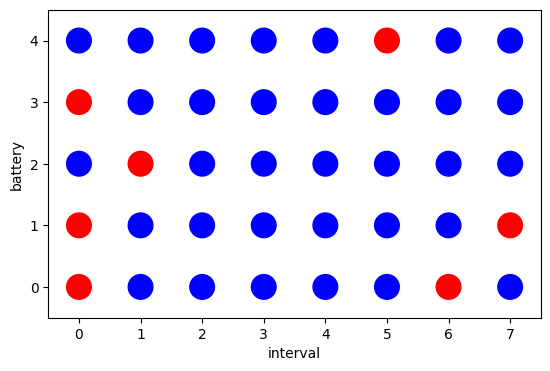

In [78]:
my_bit_discharging_array.draw(order=[1,0])

In [79]:
discharging_array = my_bit_discharging_array.data
discharging_array[discharging_array == 1] = -1
discharging_array

array([[-1,  0,  0,  0,  0,  0, -1,  0],
       [-1,  0,  0,  0,  0,  0,  0, -1],
       [ 0, -1,  0,  0,  0,  0,  0,  0],
       [-1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, -1,  0,  0]], dtype=int8)

In [80]:
charging_array = my_bit_charging_array.data
charging_array

array([[0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 1]], dtype=int8)

In [81]:
array1 = discharging_array
array2 = charging_array

# Create mask where condition is true: -1 in array1 and 1 in array2
mask_conflict = (array1 == -1) & (array2 == 1)

# Start by copying array1
result = array1.copy()

# Set conflict positions to 0
result[mask_conflict] = 0

# Where array1 is 0, take value from array2
mask_array1_zero = (array1 == 0)
result[mask_array1_zero] = array2[mask_array1_zero]

result

array([[-1,  0,  0,  0,  0,  1, -1,  1],
       [-1,  0,  0,  0,  0,  1,  0, -1],
       [ 0, -1,  0,  0,  0,  0,  1,  0],
       [-1,  0,  0,  0,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0, -1,  1,  1]], dtype=int8)

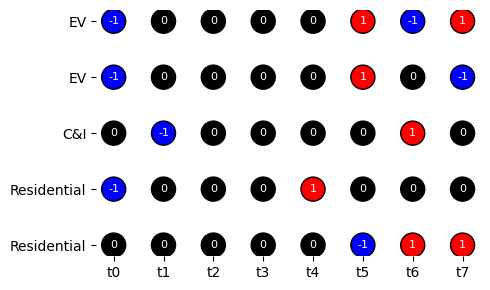

In [82]:
# Labels
row_labels = list(df_expanded['Type'])
col_labels = ['t' + str(t) for t in range(T)]

# Create figure
fig, ax = plt.subplots(figsize=(5, 3))

# Get coordinates for each value
rows, cols = np.indices(result.shape)

# Flatten for plotting
x = cols.flatten()
y = rows.flatten()
values = result.flatten()

# Map values to colors
color_map = {0: 'black', 1: 'red', -1: 'blue'}
colors = [color_map[val] for val in values]

# Scatter plot
ax.scatter(x, y, c=colors, s=300, marker='o', edgecolors='k')

# Set ticks and labels
ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)

# Invert y-axis to match matrix layout
ax.invert_yaxis()

# Remove grid and axis frame
ax.grid(False)
ax.set_frame_on(False)

# Optionally: Add value annotations
for i, val in enumerate(values):
    ax.text(x[i], y[i], str(val), color='white', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Constraint satisfiability assessment

#### Constraint 1: Exclusivity (HARD -No charging and discharging at the same time-)

In [83]:
# Element-wise multiplication
product = my_bit_charging_array.data * my_bit_discharging_array.data

# Find indices where the result is 1
indices = np.argwhere(product == 1)

# Print result
error = 0
for row, col in indices:
    error += 1 
    print(f"Match at battery {row}, time period {col}")

if error == 0:
    print(f'Constraint -No charging and discharging at the same time- satisfied')
else:
    print(f'Constraint -No charging and discharging at the same time- NOT satisfied')

Constraint -No charging and discharging at the same time- satisfied


#### Constraint 2: Consecutive charging/discharging (SOFT -No consecutive charging and discharging periods-)

In [84]:
arr = my_bit_charging_array.data

# Function to check for 3+ consecutive 1s in a binary row
def has_three_consecutive_ones(row):
    return any(np.convolve(row, np.ones(3, dtype=int), mode='valid') == 3)

# Apply row-wise
consecutive_flags = np.apply_along_axis(has_three_consecutive_ones, axis=1, arr=arr)

# Print results
for i, flag in enumerate(consecutive_flags):
    print(f"Battery {i} with 3 or more consecutive charging events: {'YES' if flag else 'NO'}")


arr = my_bit_discharging_array.data

# Function to check for 3+ consecutive 1s in a binary row
def has_three_consecutive_ones(row):
    return any(np.convolve(row, np.ones(3, dtype=int), mode='valid') == 3)

# Apply row-wise
consecutive_flags = np.apply_along_axis(has_three_consecutive_ones, axis=1, arr=arr)

# Print results
for i, flag in enumerate(consecutive_flags):
    print(f"Battery {i} with 3 or more consecutive discharging events: {'YES' if flag else 'NO'}")

Battery 0 with 3 or more consecutive charging events: NO
Battery 1 with 3 or more consecutive charging events: NO
Battery 2 with 3 or more consecutive charging events: NO
Battery 3 with 3 or more consecutive charging events: NO
Battery 4 with 3 or more consecutive charging events: NO
Battery 0 with 3 or more consecutive discharging events: NO
Battery 1 with 3 or more consecutive discharging events: NO
Battery 2 with 3 or more consecutive discharging events: NO
Battery 3 with 3 or more consecutive discharging events: NO
Battery 4 with 3 or more consecutive discharging events: NO


#### Constraint 3: Transformer capacity limit (HARD - Total load [=exogenous + batteries operations] must not exceed a transformer capacity-)

In [57]:
df_expanded

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,1,200,20,10,90,90,100,60
1,EV,1,200,20,10,90,90,100,60
2,C&I,1,2000,200,100,90,90,1000,600
3,Residential,1,20,10,5,90,90,10,6
4,Residential,1,20,10,5,90,90,10,6


In [58]:
output_df

,timestamp,excess_capacity(kW)
0,1,2392
1,2,1950
2,3,2136
3,4,2418
4,5,1776
5,6,2721
6,7,2416
7,8,2267


In [85]:
arr_charge = my_bit_charging_array.data
arr_discharge = my_bit_discharging_array.data

c_eff = list(df_expanded['C_eff(%)'])
c_rate = list(df_expanded['Charging_rate(kW)'])
c_eff_times_c_rate = [(c_eff[i]/100)*c_rate[i] for i in range(len(c_rate))]
d_eff = list(df_expanded['D_eff(%)'])
d_rate = list(df_expanded['Dicharging_rate(kW)'])
d_eff_times_d_rate = [(d_eff[i]/100)*d_rate[i] for i in range(len(d_rate))]

# Row multipliers
multipliers_charge = np.array(c_eff_times_c_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_charge = arr_charge * multipliers_charge


# Row multipliers
multipliers_discharge = np.array(d_eff_times_d_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_discharge = arr_discharge * multipliers_discharge

balance_charge_discharge = result_charge + result_discharge #### It's a plus because result_discharge is already negative

balance_charge_discharge

# Compute column sums
col_sums = balance_charge_discharge.sum(axis=0)

thresholds = list(output_df['excess_capacity(kW)'])

# Compare each column sum to the corresponding threshold
exceeds = col_sums > thresholds

# Print results
print("Batteries power exchange balance (kW):", list(col_sums))
print("Thresholds (kW):", thresholds)
print("Exceeds?   :", list(exceeds))

Batteries power exchange balance (kW): [-22.5, -90.0, 0.0, 0.0, 9.0, 31.5, 180.0, 18.0]
Thresholds (kW): [2392, 1950, 2136, 2418, 1776, 2721, 2416, 2267]
Exceeds?   : [False, False, False, False, False, False, False, False]


In [60]:
balance_charge_discharge

array([[  0. ,   0. ,   0. ,   0. ,   0. ,  -9. ,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,  -9. ,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. , -90. ,   0. ,   0. ,   0. ],
       [  0. ,  -4.5,   0. ,   0. ,   0. ,   0. ,   9. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,  -4.5,   0. ,   0. ]])

#### Constraint 4: Final SOC ≥ 30% of Capacity (SOFT -Final required stored energy per battery must be ≥ 30% of battery Capacity for emergency cases and or range anxiety-)

###### Assumptions:

1) Each battery is full at the start of the trading window, hence Initial energy per battery is equal to battery capacity

2) Final energy stored in each battery should be equal or larger than 30% of total capacity

3) Each trading interval corresponds to one hour, hence At = 1

In [61]:
df_expanded

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,1,200,20,10,90,90,100,60
1,EV,1,200,20,10,90,90,100,60
2,C&I,1,2000,200,100,90,90,1000,600
3,Residential,1,20,10,5,90,90,10,6
4,Residential,1,20,10,5,90,90,10,6


In [86]:
full_capacities = list(df_expanded['Capacity(kWh)'].astype(int))

initial_energy = list(df_expanded['E_initial(kWh)'].astype(int))

final_energy = list(df_expanded['E_required(kWh)'].astype(int))

At = 1 ### Trading interval corresponds to one hour

arr_charge = my_bit_charging_array.data
arr_discharge = my_bit_discharging_array.data

c_eff = list(df_expanded['C_eff(%)'])
c_rate = list(df_expanded['Charging_rate(kW)'])
c_eff_times_c_rate = [(c_eff[i]/100)*c_rate[i] for i in range(len(c_rate))]

d_eff = list(df_expanded['D_eff(%)'])
d_rate = list(df_expanded['Dicharging_rate(kW)'])
d_eff_times_d_rate = [(d_eff[i]/100)*d_rate[i] for i in range(len(d_rate))]

# Row multipliers
multipliers_charge = np.array(c_eff_times_c_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_charge = arr_charge * multipliers_charge


# Row multipliers
multipliers_discharge = np.array(d_eff_times_d_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_discharge = arr_discharge * multipliers_discharge

balance_charge_discharge = result_charge + result_discharge ### It's a plus because result_discharge is already negative

balance_charge_discharge

# Compute rows sums
row_sums = balance_charge_discharge.sum(axis=1)

energy_balance_per_battery = list(At * row_sums)

energy_balance_per_battery

balance_ini_minus_exch = [(initial_energy[i] + energy_balance_per_battery[i]) for i in range (len(energy_balance_per_battery))]

# Print the elements where list1 is NOT greater than list2
for i, (a, b) in enumerate(zip(balance_ini_minus_exch, final_energy)):
    if not a > b:
        print(f"False at battery {i} where Final SOC ≥ 30% not met: list1[{i}] = {a}, list2[{i}] = {b}")
    else:
        print(f"Battery {i} meets Final SOC ≥ 30%")        

Battery 0 meets Final SOC ≥ 30%
Battery 1 meets Final SOC ≥ 30%
Battery 2 meets Final SOC ≥ 30%
Battery 3 meets Final SOC ≥ 30%
Battery 4 meets Final SOC ≥ 30%


#### SOC evolution per battery

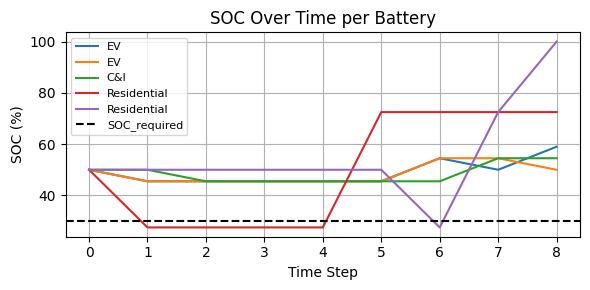

In [87]:
At = 1 ### Trading interval corresponds to one hour

Emax = list(df_expanded['Capacity(kWh)'])

battery_names = list(df_expanded['Type'])

arr_charge = my_bit_charging_array.data
arr_discharge = my_bit_discharging_array.data

c_eff = list(df_expanded['C_eff(%)'])
c_rate = list(df_expanded['Charging_rate(kW)'])
c_eff_times_c_rate = [(c_eff[i]/100)*c_rate[i] for i in range(len(c_rate))]
d_eff = list(df_expanded['D_eff(%)'])
d_rate = list(df_expanded['Dicharging_rate(kW)'])
d_eff_times_d_rate = [(d_eff[i]/100)*d_rate[i] for i in range(len(d_rate))]

# Row multipliers
multipliers_charge = np.array(c_eff_times_c_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_charge = arr_charge * multipliers_charge


# Row multipliers
multipliers_discharge = np.array(d_eff_times_d_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_discharge = arr_discharge * multipliers_discharge

balance_charge_discharge = result_charge + result_discharge #### It's a plus because result_discharge is already negative

energy_array = balance_charge_discharge

# Initial SOC for each battery
SOC_initial = np.ones(energy_array.shape[0])  # shape = (5,)
SOC_initial = np.array(list(df_expanded['E_initial(kWh)'].astype(int)))/Emax  # shape = (5,)

# Transpose energy_array to shape (time, battery)
energy_array = energy_array.T  # shape becomes (8, 5)

# Initialize SOC array (time+1 steps x batteries)
SOC = np.zeros((energy_array.shape[0] + 1, energy_array.shape[1]))
SOC[0] = SOC_initial

# Compute SOC over time
for t in range(energy_array.shape[0]):
    SOC[t + 1] = SOC[t] + energy_array[t] / Emax
    SOC[t + 1] = np.clip(SOC[t + 1], 0, 1)  # Keep within [0, 1]

# Plot
plt.figure(figsize=(6, 3))
for i, name in enumerate(battery_names):
    plt.plot(SOC[:, i] * 100, label=name)

# Add SOC_required line at 30%
plt.axhline(req_final_energy_perc, linestyle='--', color='black', label='SOC_required')
plt.xlabel("Time Step")
plt.ylabel("SOC (%)")
plt.title("SOC Over Time per Battery")
plt.grid(True)
plt.legend(fontsize=8)  # Smaller legend font
plt.tight_layout()
plt.show()

In [64]:
balance_charge_discharge

array([[  0. ,   0. ,   0. ,   0. ,   0. ,  -9. ,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,  -9. ,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. , -90. ,   0. ,   0. ,   0. ],
       [  0. ,  -4.5,   0. ,   0. ,   0. ,   0. ,   9. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,  -4.5,   0. ,   0. ]])

In [65]:
df_expanded

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,1,200,20,10,90,90,100,60
1,EV,1,200,20,10,90,90,100,60
2,C&I,1,2000,200,100,90,90,1000,600
3,Residential,1,20,10,5,90,90,10,6
4,Residential,1,20,10,5,90,90,10,6


#### Profit and Loss evolution (PnL)

In [66]:
df

,Time Period,Buy Price ($/kWh),Sell Price ($/kWh),Forecasted Load (kW),Balance_discharged_charged(kWh),PnL($/kWh)
0,1,0.09,0.08,7608.0,103.5,8.280
1,2,0.12,0.09,8050.0,4.5,0.405
2,3,0.11,0.06,7864.0,-0.0,-0.000
3,4,0.10,0.10,7582.0,-0.0,-0.000
4,5,0.09,0.09,8224.0,-0.0,-0.000
5,6,0.09,0.07,7279.0,-18.0,-1.620
6,7,0.08,0.07,7584.0,-207.0,-16.560
7,8,0.11,0.07,7733.0,-193.5,-21.825


In [67]:
result_charge

array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 9., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

In [88]:
prices_buy = np.array(list(df['Buy Price ($/kWh)']))

# Step 1: sum energy column-wise
total_energy_per_time_charge = At * result_charge.sum(axis=0)  # shape = (8,)

# Step 2: multiply element-wise by prices
weighted_energy_value_charge = total_energy_per_time_charge * prices_buy  # shape = (8,)

# Total revenue or cost
total_value_cost = weighted_energy_value_charge.sum()

# Output
print("Energy charged per timestamp (kWh):", total_energy_per_time_charge)
print("Price-weighted energy charged:", weighted_energy_value_charge)
print("Total cost: $", total_value_cost)


prices_sell = np.array(list(df['Sell Price ($/kWh)']))

# Step 1: sum energy column-wise
total_energy_per_time_discharge = At * (-1)*result_discharge.sum(axis=0)  # shape = (8,)

# Step 2: multiply element-wise by prices
weighted_energy_value_discharge = total_energy_per_time_discharge * prices_sell  # shape = (8,)

# Total revenue or cost
total_value_revenue = weighted_energy_value_discharge.sum()

# Output
print("Energy discharged per timestamp (kWh):", total_energy_per_time_discharge)
print("Price-weighted energy discharged:", weighted_energy_value_discharge)
print("Total revenue: $", total_value_revenue)


############# Balance Energy Exchange = (Energy discharged per timestamp (kWh)) - (Energy charged per timestamp (kWh))

BEE = total_energy_per_time_discharge - total_energy_per_time_charge
PnL = weighted_energy_value_discharge - weighted_energy_value_charge

df['Balance_discharged_charged(kWh)'] = BEE
df['PnL($/kWh)'] = PnL

Energy charged per timestamp (kWh): [  0.   0.   0.   0.   9.  36. 189.  27.]
Price-weighted energy charged: [ 0.    0.    0.    0.    0.81  3.24 15.12  2.97]
Total cost: $ 22.14
Energy discharged per timestamp (kWh): [22.5 90.  -0.  -0.  -0.   4.5  9.   9. ]
Price-weighted energy discharged: [ 1.8    8.1   -0.    -0.    -0.     0.315  0.63   0.63 ]
Total revenue: $ 11.475000000000001


In [69]:
df

,Time Period,Buy Price ($/kWh),Sell Price ($/kWh),Forecasted Load (kW),Balance_discharged_charged(kWh),PnL($/kWh)
0,1,0.09,0.08,7608.0,-0.0,-0.000
1,2,0.12,0.09,8050.0,4.5,0.405
2,3,0.11,0.06,7864.0,-0.0,-0.000
3,4,0.10,0.10,7582.0,-0.0,-0.000
4,5,0.09,0.09,8224.0,90.0,8.100
5,6,0.09,0.07,7279.0,22.5,1.575
6,7,0.08,0.07,7584.0,-9.0,-0.720
7,8,0.11,0.07,7733.0,-0.0,-0.000


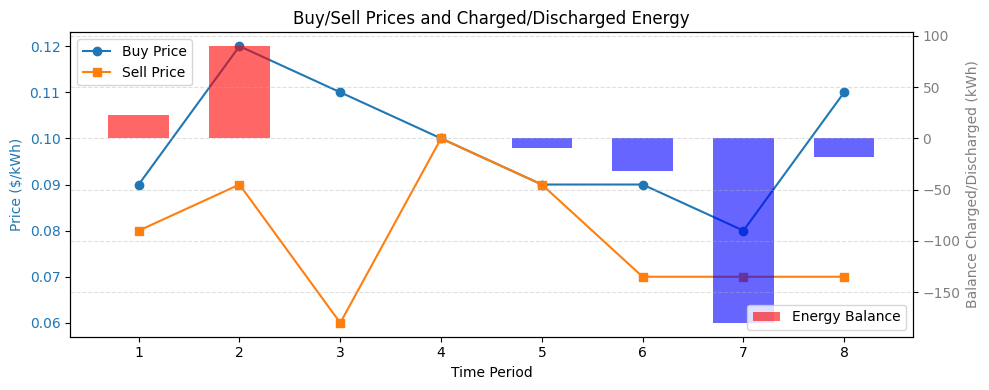

In [89]:
# Prepare bar colors based on sign
bar_colors = df["Balance_discharged_charged(kWh)"].apply(lambda x: 'red' if x > 0 else ('blue' if x < 0 else 'gray'))

# Plot
fig, ax1 = plt.subplots(figsize=(10, 4))

# Buy/Sell price lines
ax1.set_title("Buy/Sell Prices and Charged/Discharged Energy")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Price ($/kWh)", color='tab:blue')
ax1.plot(df["Time Period"], df["Buy Price ($/kWh)"], label="Buy Price", marker='o', color='tab:blue')
ax1.plot(df["Time Period"], df["Sell Price ($/kWh)"], label="Sell Price", marker='s', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc="upper left")

# Secondary axis for bar plot
ax2 = ax1.twinx()
ax2.set_ylabel("Balance Charged/Discharged (kWh)", color='tab:gray')
ax2.bar(
    df["Time Period"],
    df["Balance_discharged_charged(kWh)"],
    color=bar_colors,
    alpha=0.6,
    width=0.6,
    label="Energy Balance"
)
ax2.tick_params(axis='y', labelcolor='tab:gray')
ax2.legend(loc="lower right")

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

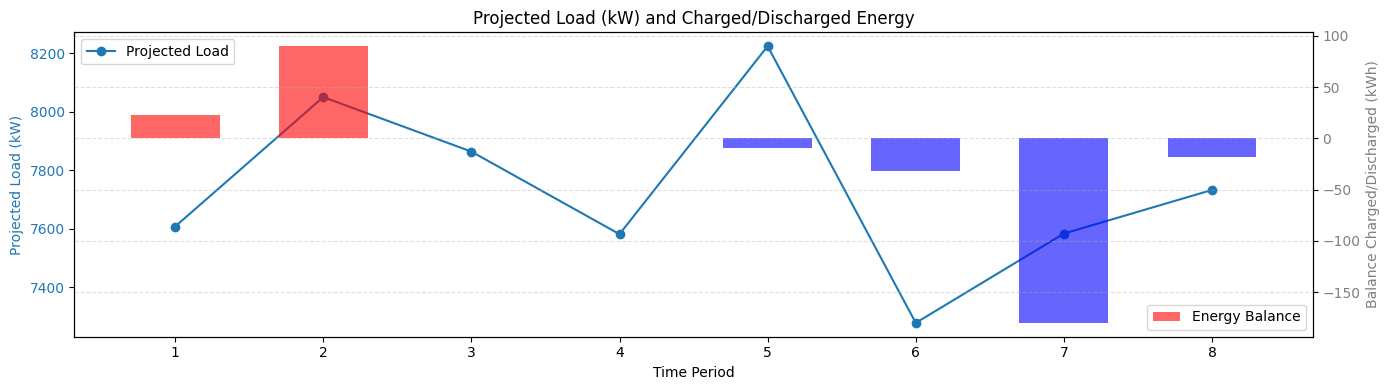

In [90]:
# Prepare bar colors based on sign
bar_colors = df["Balance_discharged_charged(kWh)"].apply(lambda x: 'red' if x > 0 else ('blue' if x < 0 else 'gray'))

# Plot
fig, ax1 = plt.subplots(figsize=(14, 4))

# Buy/Sell price lines
ax1.set_title("Projected Load (kW) and Charged/Discharged Energy")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Projected Load (kW)", color='tab:blue')
ax1.plot(df["Time Period"], df["Forecasted Load (kW)"], label="Projected Load", marker='o', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc="upper left")

# Secondary axis for bar plot
ax2 = ax1.twinx()
ax2.set_ylabel("Balance Charged/Discharged (kWh)", color='tab:gray')
ax2.bar(
    df["Time Period"],
    df["Balance_discharged_charged(kWh)"],
    color=bar_colors,
    alpha=0.6,
    width=0.6,
    label="Energy Balance"
)
ax2.tick_params(axis='y', labelcolor='tab:gray')
ax2.legend(loc="lower right")

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

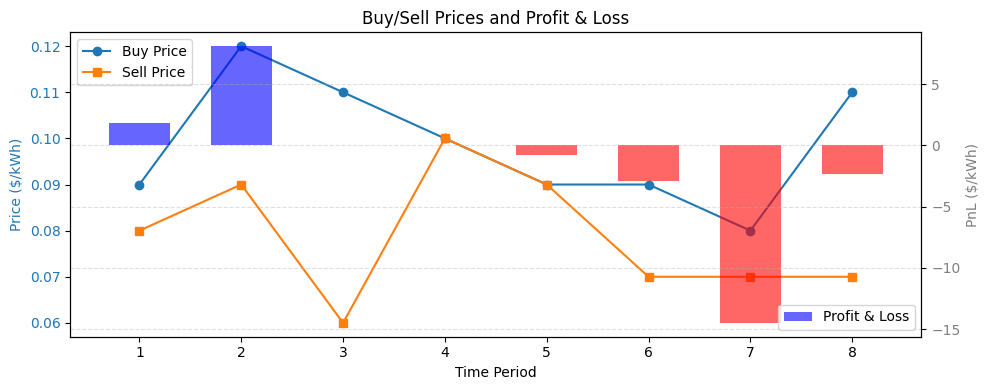

In [91]:
# Define bar colors based on PnL sign
pnl_colors = df["PnL($/kWh)"].apply(lambda x: 'blue' if x > 0 else ('red' if x < 0 else 'gray'))

# Plot
fig, ax1 = plt.subplots(figsize=(10, 4))

# Buy/Sell price lines
ax1.set_title("Buy/Sell Prices and Profit & Loss")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Price ($/kWh)", color='tab:blue')
ax1.plot(df["Time Period"], df["Buy Price ($/kWh)"], label="Buy Price", marker='o', color='tab:blue')
ax1.plot(df["Time Period"], df["Sell Price ($/kWh)"], label="Sell Price", marker='s', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc="upper left")

# Secondary axis for PnL bars
ax2 = ax1.twinx()
ax2.set_ylabel("PnL ($/kWh)", color='tab:gray')
ax2.bar(
    df["Time Period"],
    df["PnL($/kWh)"],
    color=pnl_colors,
    alpha=0.6,
    width=0.6,
    label="Profit & Loss"
)
ax2.tick_params(axis='y', labelcolor='tab:gray')
ax2.legend(loc="lower right")

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [92]:
print("PnL: $", PnL.sum())
print("BEE: kWh", BEE.sum())

PnL: $ -10.664999999999997
BEE: kWh -126.0
